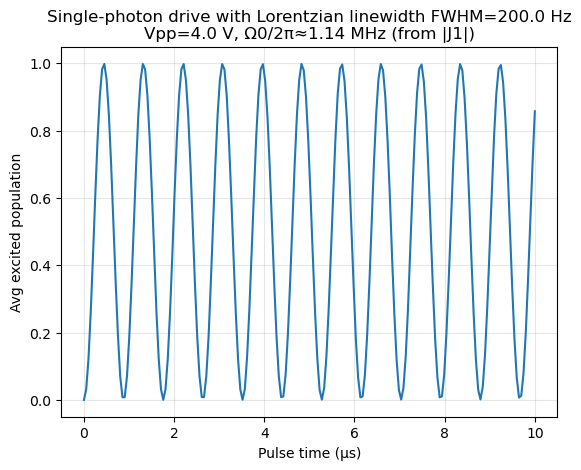

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1

# -------------------------
# EOM + Rabi model: single photon, Ω0 ∝ |J1(β)|
# -------------------------
Vpi = 3.0     # V
def Omega0_from_Vpp(Vpp, Omega_max=2*np.pi*1e6):
    Vpk = Vpp/2
    beta = np.pi*(Vpk/Vpi)
    return Omega_max*np.abs(j1(beta))

# -------------------------
# Phase diffusion -> Lorentzian linewidth
# For phase diffusion: var(dphi) = 2 D dt
# Rough mapping: Lorentzian FWHM (Hz) ~ D/pi  => D ~ pi*FWHM
# -------------------------
FWHM = 200.0          # Hz linewidth of the RF drive
D = np.pi * FWHM      # rad^2/s

# -------------------------
# Simple 2-level dynamics in rotating frame (on resonance)
# with stochastic phase in the drive:
# H ~ (Ω0/2) [cos(phi) σx + sin(phi) σy]
# We integrate the Schrödinger equation for state vector.
# -------------------------
def simulate_flop(Omega0, T=10e-6, dt=2e-9, seed=0):
    rng = np.random.default_rng(seed)
    N = int(T/dt)
    # state |psi> = [cg, ce]
    psi = np.array([1.0+0j, 0.0+0j])

    phi = 0.0
    for _ in range(N):
        # phase diffusion step
        dphi = np.sqrt(2*D*dt) * rng.standard_normal()
        phi += dphi

        # drive Hamiltonian in rotating frame (on resonance)
        # H = (Ω0/2) * [[0, e^{-i phi}], [e^{+i phi}, 0]]
        off = 0.5*Omega0*np.exp(-1j*phi)
        H = np.array([[0, off],
                      [np.conj(off), 0]], dtype=complex)

        # time step: psi <- exp(-i H dt) psi  (1st order is fine for small dt)
        psi = psi - 1j*(H @ psi)*dt

        # renormalize to suppress numerical drift
        psi = psi / np.linalg.norm(psi)

    return np.abs(psi[1])**2  # excited population at final time

# -------------------------
# Show how linewidth changes observed flops vs pulse time
# -------------------------
Vpp = 4.0
Omega0 = Omega0_from_Vpp(Vpp, Omega_max=2*np.pi*2e6)  # set max scale as you like

times = np.linspace(0, 10e-6, 200)
Pe_avg = []
n_avg = 80   # Monte Carlo average to represent experimental averaging

for T in times:
    vals = [simulate_flop(Omega0, T=T, dt=2e-9, seed=k) for k in range(n_avg)]
    Pe_avg.append(np.mean(vals))

plt.figure()
plt.plot(times*1e6, Pe_avg)
plt.xlabel("Pulse time (µs)")
plt.ylabel("Avg excited population")
plt.title(f"Single-photon drive with Lorentzian linewidth FWHM={FWHM} Hz\n"
          f"Vpp={Vpp} V, Ω0/2π≈{Omega0/(2*np.pi*1e6):.2f} MHz (from |J1|)")
plt.grid(True, alpha=0.3)
plt.show()


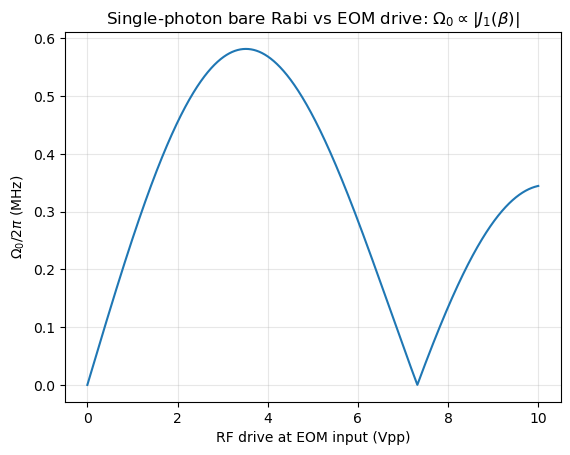

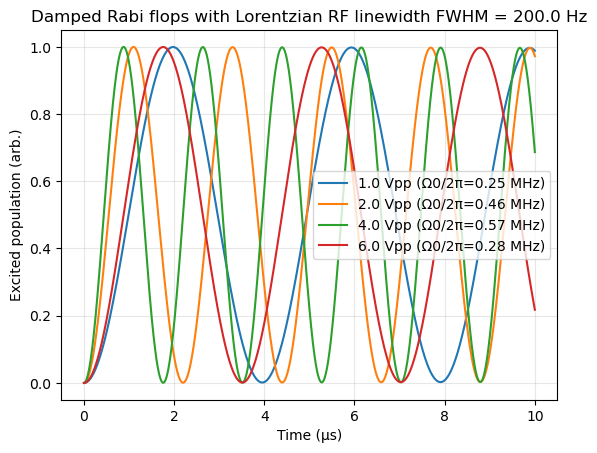

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1

# --------- EOM parameters ----------
Vpi = 3.0          # V
use_vpp = True     # your knob is Vpp at the EOM input
Vpp_list = [1.0, 2.0, 4.0, 6.0]  # example drive levels to compare

# --------- "Bare" Rabi scaling ----------
Omega_max = 2*np.pi*1.0e6   # rad/s, set this to your max Rabi at the peak sideband field

def beta_from_vpp(Vpp):
    Vpk = Vpp/2 if use_vpp else Vpp
    return np.pi * (Vpk / Vpi)

def Omega0_from_vpp(Vpp):
    beta = beta_from_vpp(Vpp)
    return Omega_max * np.abs(j1(beta))

# --------- Lorentzian linewidth -> dephasing ----------
Delta_nu_RF = 200.0  # Hz (FWHM). set this to your generator tone linewidth (or effective linewidth)
gamma_phi = np.pi * Delta_nu_RF  # 1/s

# Optional population decay (set 0 if negligible)
gamma1 = 0.0
gamma2 = gamma_phi + gamma1/2

# --------- Simple damped Rabi flops on resonance ----------
# This is a practical, common approximation: oscillate at Omega0 with exp(-gamma2 t) envelope.
# Good for "how will linewidth affect what I observe?"
def Pe_t(t, Omega0):
    return 0.5*(1 - np.exp(-gamma2*t)*np.cos(Omega0*t))

# --------- Plot Ω0 vs Vpp ----------
Vpp = np.linspace(0, 10, 2000)
Omega0 = np.array([Omega0_from_vpp(v) for v in Vpp])

plt.figure()
plt.plot(Vpp, Omega0/(2*np.pi*1e6))
plt.xlabel("RF drive at EOM input (Vpp)")
plt.ylabel(r"$\Omega_0/2\pi$ (MHz)")
plt.title(r"Single-photon bare Rabi vs EOM drive: $\Omega_0 \propto |J_1(\beta)|$")
plt.grid(True, alpha=0.3)
plt.show()

# --------- Plot time flops for a few Vpp values ----------
t = np.linspace(0, 10e-6, 3000)  # 10 µs window

plt.figure()
for v in Vpp_list:
    Om = Omega0_from_vpp(v)
    plt.plot(t*1e6, Pe_t(t, Om), label=f"{v} Vpp (Ω0/2π={Om/(2*np.pi*1e6):.2f} MHz)")
plt.xlabel("Time (µs)")
plt.ylabel("Excited population (arb.)")
plt.title(f"Damped Rabi flops with Lorentzian RF linewidth FWHM = {Delta_nu_RF} Hz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
